
Training MLP with MAE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0865 - val_loss: 0.0688
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 0.0608 - val_loss: 0.0653
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step - loss: 0.0558 - val_loss: 0.0636
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 0.0509 - val_loss: 0.0623
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0533 - val_loss: 0.0628
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - loss: 0.0549 - val_loss: 0.0625
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - loss: 0.0521 - val_loss: 0.0632
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - loss: 0.0484 - val_loss: 0.0639
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0528 - val_loss: 0.0644
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


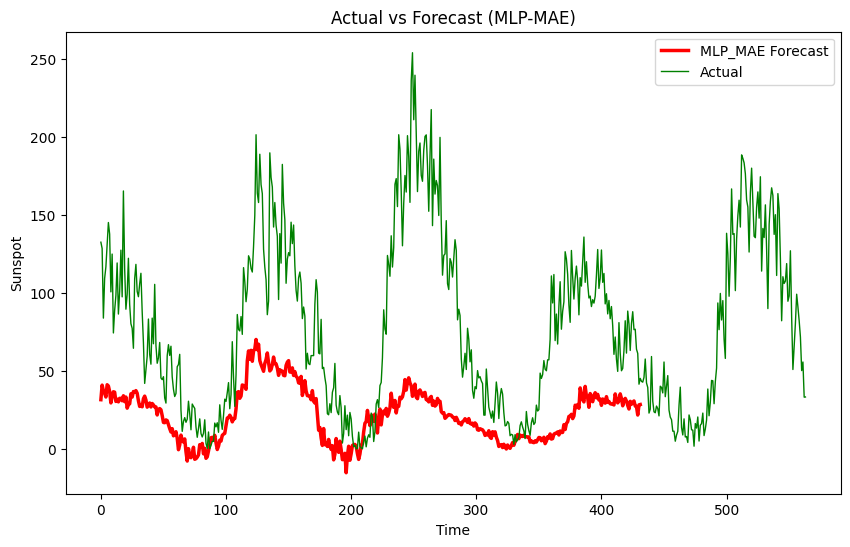


Evaluation Metrics
MSE   : 5419.037672552427
RMSE  : 73.61411327016326
NRMSE: 0.29027647188550176
MAE   : 57.86429687644801
SMAPE : 111.69675842809104
MASE  : 3.9074832673324074


In [1]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MAE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MAE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanAbsoluteError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MAE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MAE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (ALL PATHS FILLED)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\x_train_sunspot_full_20.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\y_train_sunspot_full_20.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_sunspot_final_20.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_daily_sunspot_loss_history_20.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_20.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_20.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled_20.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled_20.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with MSE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0227 - val_loss: 0.0172
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0165 - val_loss: 0.0169
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0135 - val_loss: 0.0176
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - loss: 0.0128 - val_loss: 0.0173
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0112 - val_loss: 0.0180
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0090 - val_loss: 0.0184
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0089 - val_loss: 0.0190
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


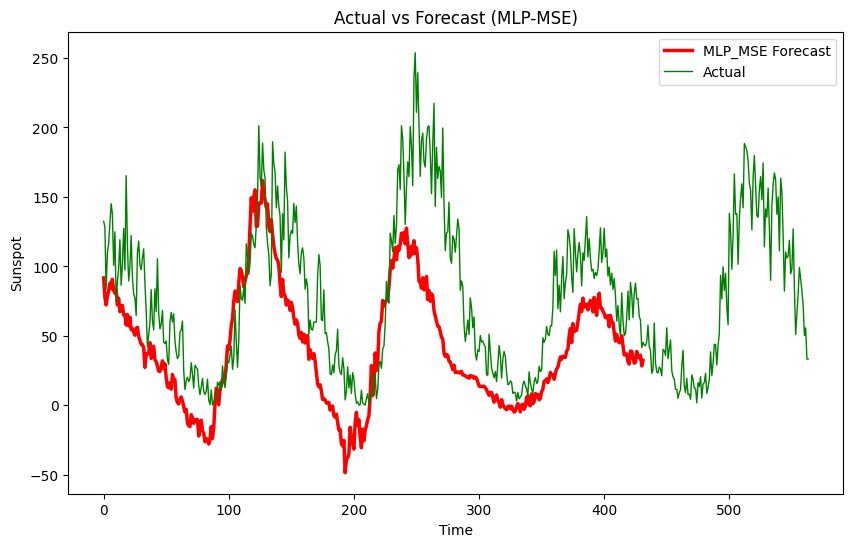


Evaluation Metrics
MSE   : 2516.7911155936954
RMSE  : 50.16763015724079
NRMSE: 0.1978218854780788
MAE   : 40.86819214093308
SMAPE : 91.48094790491501
MASE  : 2.7597635429286576


In [2]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MSE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MSE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanSquaredError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MSE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MSE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (MSE NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\x_train_sunspot_full_20.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\y_train_sunspot_full_20.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_final_20.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_loss_history_20.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_20.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_20.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled_20.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled_20.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Huber loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0053 - val_loss: 0.0041
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0038 - val_loss: 0.0041
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0035 - val_loss: 0.0041
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0035 - val_loss: 0.0043
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


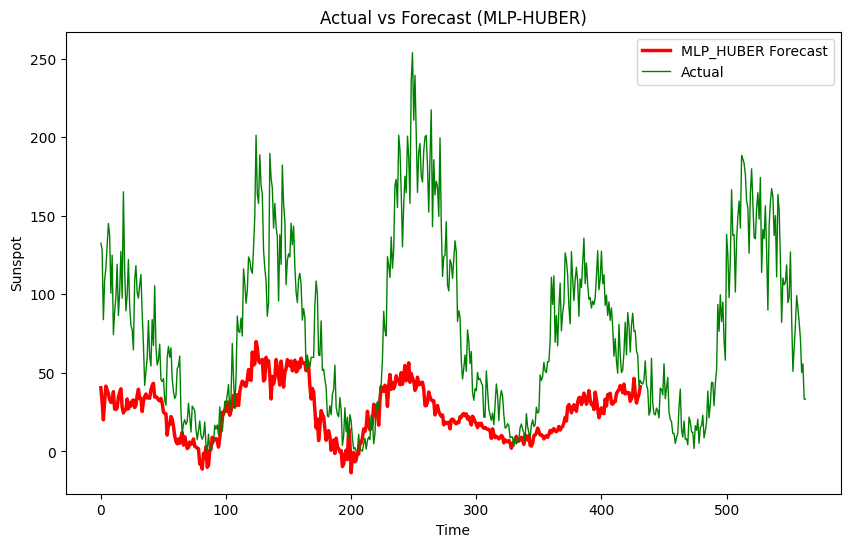


Evaluation Metrics
MSE   : 5187.364532772842
RMSE  : 72.0233610210801
NRMSE: 0.2840037895153001
MAE   : 55.14577193899733
SMAPE : 98.94879373627943
MASE  : 3.7239056334834073


In [3]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. HUBER LOSS (CUSTOM DEFINITION)
# =========================================================
def huber_loss(delta=1.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, delta)
        linear = abs_error - quadratic
        return tf.reduce_mean(0.5 * tf.square(quadratic) + delta * linear)
    return loss


# =========================================================
# 4. TRAIN MODEL (HUBER LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Huber loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=huber_loss(delta=cfg['huber_delta'])
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'loss': huber_loss(cfg['huber_delta'])}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_HUBER Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-HUBER)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HUBER NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'huber_delta': 0.102,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\x_train_sunspot_full_20.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\y_train_sunspot_full_20.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_final_20.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_loss_history_20.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_20.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_20.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled_20.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled_20.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Log-Cosh loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0073 - val_loss: 0.0074
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - loss: 0.0044 - val_loss: 0.0073
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046 - val_loss: 0.0073
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.0043 - val_loss: 0.0076
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0030 - val_loss: 0.0075
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0029 - val_loss: 0.0077
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0026 - val_loss: 0.0085
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


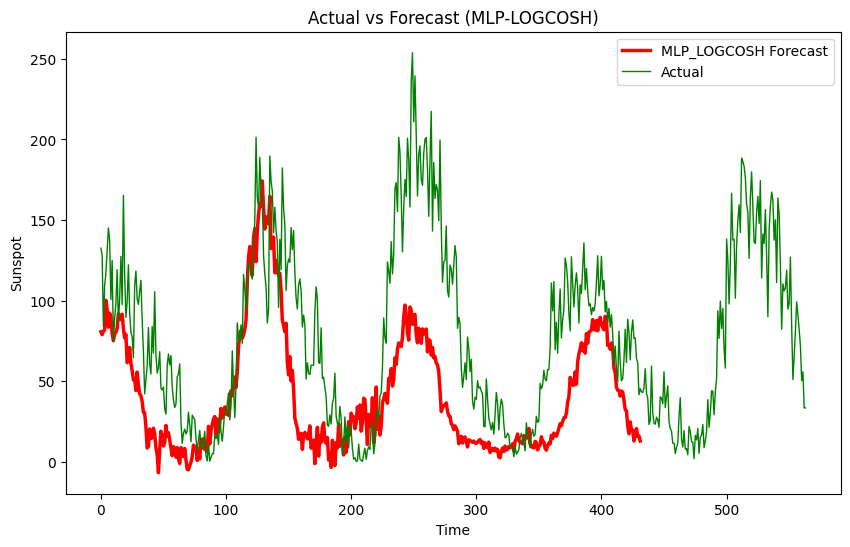


Evaluation Metrics
MSE   : 2662.5311790230667
RMSE  : 51.59972072621195
NRMSE: 0.2034689303084067
MAE   : 40.597854328252964
SMAPE : 78.76436096349958
MASE  : 2.741508063529499


In [11]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. LOG-COSH LOSS (CUSTOM DEFINITION)
# =========================================================
def logcosh_loss(y_true, y_pred):
    return tf.reduce_mean(tf.math.log(tf.cosh(y_pred - y_true)))


# =========================================================
# 4. TRAIN MODEL (LOG-COSH LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Log-Cosh loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=logcosh_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'logcosh_loss': logcosh_loss}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_LOGCOSH Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-LOGCOSH)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (LOG-COSH NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_final_10.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_10.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled_10.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled_10.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP using RoBoSS loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0290e-04 - val_loss: 3.0896e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.3326e-04 - val_loss: 2.9493e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 2.0090e-04 - val_loss: 3.0648e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - loss: 1.6971e-04 - val_loss: 2.8722e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4917e-04 - val_loss: 3.0496e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1299e-04 - val_loss: 2.8012e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


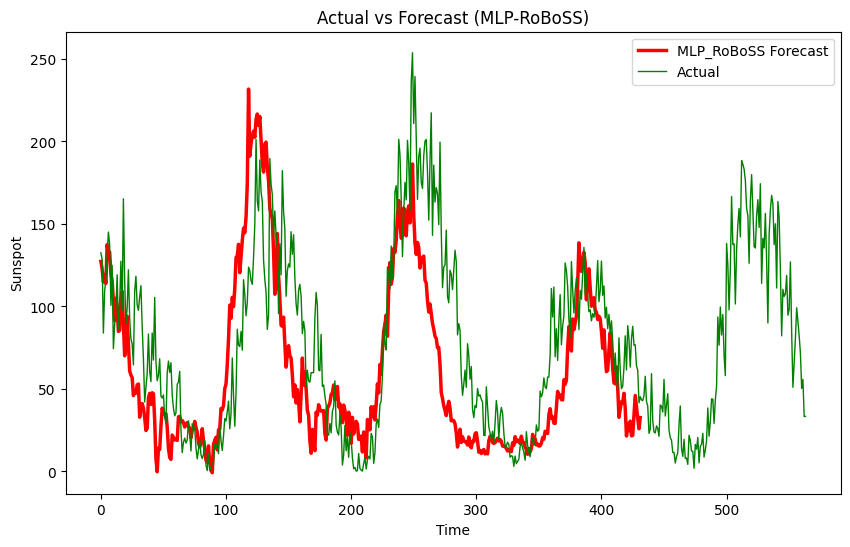


Evaluation Metrics
MSE   : 1554.2068500623793
RMSE  : 39.42343021684414
NRMSE: 0.15545516647020557
MAE   : 30.992701764906762
SMAPE : 55.58189470019843
MASE  : 2.0928874987347927


In [6]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. ROBOSS LOSS
# =========================================================
def roboss_nn_loss(y_true, y_pred, a, epsilon, lam):
    u = tf.abs(y_true - y_pred)
    val = a * tf.sqrt(tf.square(u) + epsilon) - a * tf.sqrt(epsilon)
    loss_val = lam * (1 - (val + 1) * tf.exp(-val))
    return tf.reduce_mean(loss_val)


# =========================================================
# 2. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 3. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 4. TRAIN MODEL (ROBOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP using RoBoSS loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=dynamic_roboss_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'dynamic_roboss_loss': dynamic_roboss_loss,
            'roboss_nn_loss': roboss_nn_loss
        }
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)

    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_RoBoSS Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-RoBoSS)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'a': 1.009,
    'epsilon': 0.048,
    'lam': 0.150,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\x_train_sunspot_full_20.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\y_train_sunspot_full_20.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_sunspot_final_20.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_daily_sunspot_loss_history_20.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_20.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_20.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled_20.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled_20.csv"
}




# =========================================================
# 10. RUN COMPLETE PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Cauchy loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - loss: 0.0011 - val_loss: 0.0014
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 9.4224e-04 - val_loss: 0.0014
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 9.2661e-04 - val_loss: 0.0013
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.8611e-04 - val_loss: 0.0014
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.8752e-04 - val_loss: 0.0014
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.0489e-04 - val_loss: 0.0014
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


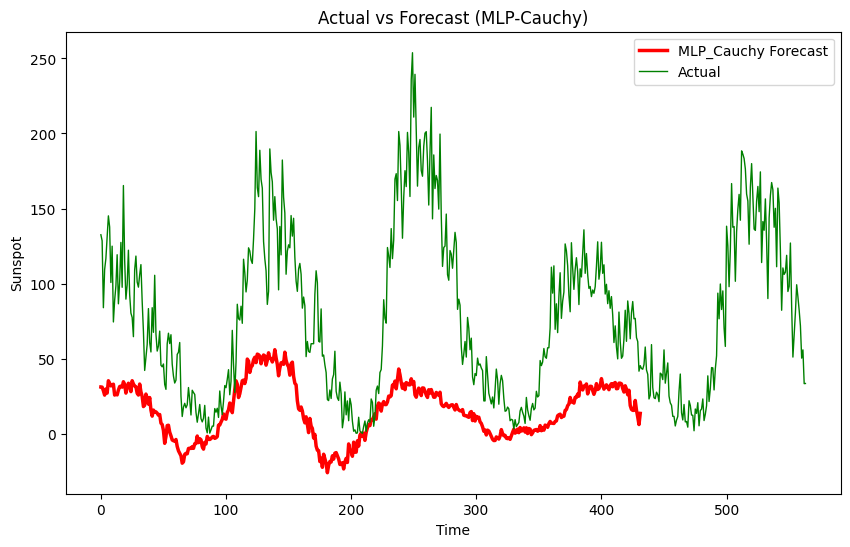


Evaluation Metrics
MSE   : 6035.512795138977
RMSE  : 77.68856283352767
NRMSE : 0.3063429133814182
MAE   : 64.67325107438826
SMAPE : 142.5547351066836
MASE  : 4.367281036123986


In [17]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. CAUCHY LOSS
# =========================================================
def cauchy_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        loss_value = (
            (c ** 2) / 2.0
        ) * tf.math.log(
            1.0 + tf.square(error) / (c ** 2)
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (CAUCHY LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Cauchy loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=cauchy_loss(
            c=cfg['cauchy_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': cauchy_loss(
                cfg['cauchy_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Cauchy Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Cauchy)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (CAUCHY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Cauchy parameter
    'cauchy_c': 0.102,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\x_train_sunspot_full_10.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_10\y_train_sunspot_full_10.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_final_10.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_loss_history_10.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_10.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_10.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled_10.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled_10.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with Tukey's Biweight loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0010 - val_loss: 6.4689e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.5935e-04 - val_loss: 5.1476e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - loss: 4.1285e-04 - val_loss: 4.8616e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step - loss: 3.6436e-04 - val_loss: 4.7822e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 3.3880e-04 - val_loss: 4.7715e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.3430e-04 - val_loss: 4.7638e-04
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - loss: 2.9362e-04 - val_loss: 4.7524e-04
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


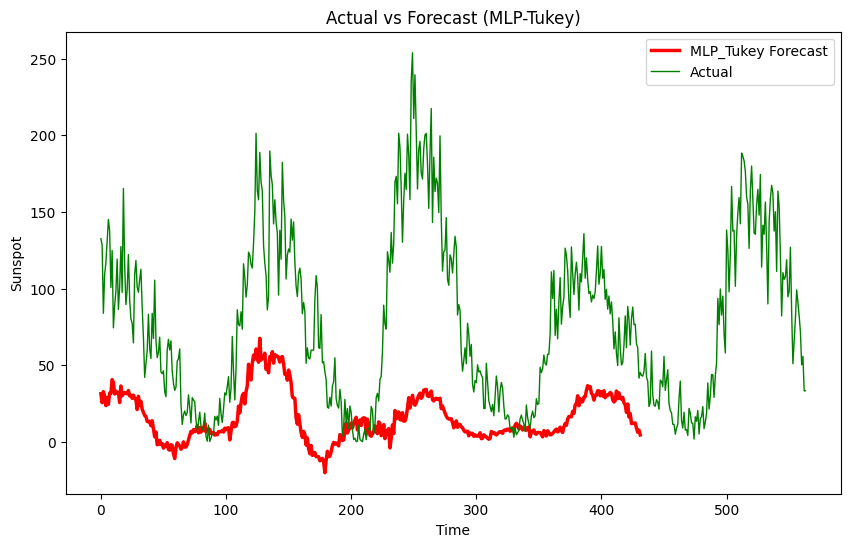


Evaluation Metrics
MSE   : 6270.686903389076
RMSE  : 79.18766888467596
NRMSE : 0.3122542148449367
MAE   : 64.65501986698312
SMAPE : 131.5578827800808
MASE  : 4.366049911894983


In [16]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. TUKEY'S BIWEIGHT LOSS
# =========================================================
def tukey_biweight_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        abs_error = tf.abs(error)

        # Region where |r| <= c
        inside = abs_error <= c

        # Tukey biweight expression
        scaled_error = error / c

        inside_loss = (
            (c ** 2) / 6.0
        ) * (
            1.0 -
            tf.pow(
                1.0 - tf.square(scaled_error),
                3
            )
        )

        # Constant loss for |r| > c
        outside_loss = (
            (c ** 2) / 6.0
        ) * tf.ones_like(error)

        loss_value = tf.where(
            inside,
            inside_loss,
            outside_loss
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (TUKEY'S BIWEIGHT LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Tukey's Biweight loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=tukey_biweight_loss(
            c=cfg['tukey_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': tukey_biweight_loss(
                cfg['tukey_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Tukey Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Tukey)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (TUKEY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Tukey's Biweight parameter
    'tukey_c': 0.103,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\x_train_sunspot_full_20.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\y_train_sunspot_full_20.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_final_20.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_loss_history_20.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_20.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_20.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled_20.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled_20.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with HawkEye loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.6817e-04 - val_loss: 6.1039e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.6551e-04 - val_loss: 6.1365e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.2068e-04 - val_loss: 6.1088e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4585e-04 - val_loss: 6.1720e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - loss: 4.1950e-04 - val_loss: 6.1491e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.7764e-04 - val_loss: 6.5295e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


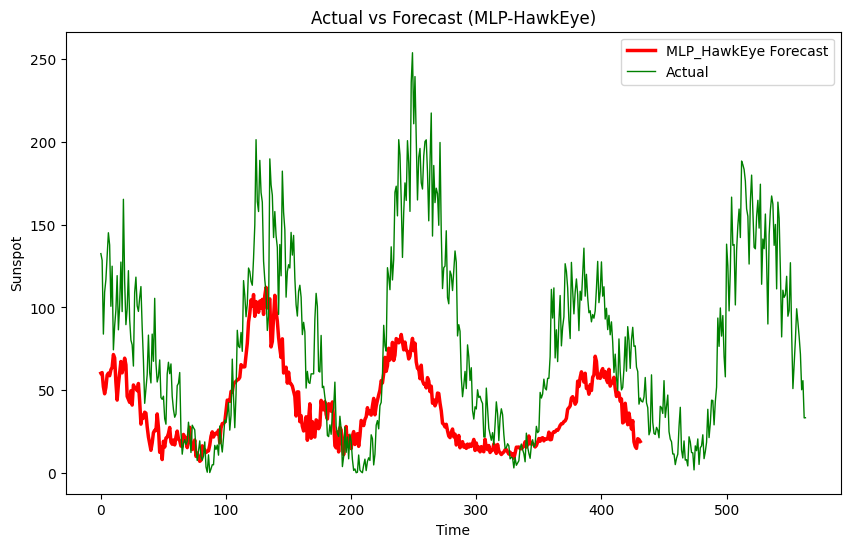


Evaluation Metrics
MSE   : 3334.613169947284
RMSE  : 57.74610956547016
NRMSE : 0.22770547935910943
MAE   : 44.22901400093128
SMAPE : 70.68941702920276
MASE  : 2.9867144589739727


In [12]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. HAWKEYE LOSS
# =========================================================
def hawkeye_loss(a=1.0, epsilon=0.02, lam=1.0):

    def loss(y_true, y_pred):

        # Residual
        r = y_true - y_pred

        # -------------------------------------------------
        # Left region: r <= -epsilon
        # -------------------------------------------------
        left_loss = lam * (
            1.0
            - (
                -a * (r + epsilon) + 1.0
            )
            * tf.exp(
                a * (r + epsilon)
            )
        )

        # -------------------------------------------------
        # Middle region: -epsilon < r < epsilon
        # -------------------------------------------------
        middle_loss = tf.zeros_like(r)

        # -------------------------------------------------
        # Right region: r >= epsilon
        # -------------------------------------------------
        right_loss = lam * (
            1.0
            - (
                a * (r - epsilon) + 1.0
            )
            * tf.exp(
                -a * (r - epsilon)
            )
        )

        # -------------------------------------------------
        # Piecewise HawkEye loss
        # -------------------------------------------------
        loss_value = tf.where(
            r <= -epsilon,
            left_loss,
            tf.where(
                r >= epsilon,
                right_loss,
                middle_loss
            )
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (HAWKEYE LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with HawkEye loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=hawkeye_loss(
            a=cfg['hawkeye_a'],
            epsilon=cfg['hawkeye_epsilon'],
            lam=cfg['hawkeye_lam']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': hawkeye_loss(
                a=cfg['hawkeye_a'],
                epsilon=cfg['hawkeye_epsilon'],
                lam=cfg['hawkeye_lam']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_HawkEye Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-HawkEye)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HAWKEYE NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # -----------------------------------------------------
    # HAWKEYE PARAMETERS
    # -----------------------------------------------------
    'hawkeye_a': 1.062,
    'hawkeye_epsilon': 0.023,
    'hawkeye_lam': 0.102,

    # -----------------------------------------------------
    # TRAIN / TEST DATA
    # -----------------------------------------------------
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\x_train_sunspot_full_20.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_20\y_train_sunspot_full_20.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # -----------------------------------------------------
    # RAW TEST CSV
    # -----------------------------------------------------
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # -----------------------------------------------------
    # MODEL & LOGS
    # -----------------------------------------------------
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_final_20.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_loss_history_20.csv",

    # -----------------------------------------------------
    # FORECASTS
    # -----------------------------------------------------
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_20.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_20.csv",

    # -----------------------------------------------------
    # RESCALED FORECASTS
    # -----------------------------------------------------
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled_20.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled_20.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)